In [31]:

import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import minimize

# === Model Parameters === #
r, mu, sigma, pi, w0 = 0.03, 0.0795, 0.15, 0.1, 1.0
pmin, pmax = 0.0, 1.0

T, dt, N = 20.0, 0.25, int(20.0 / 0.25)
K, Wmax, M = 100000, 30, 31
lambda_risk = 0.1

wealth_grid = np.linspace(0, Wmax, M)
time_grid = np.linspace(0, T - dt, N)

def bilinear_policy(p_params):
    p_grid = p_params.reshape((N, M))
    interpolator = RectBivariateSpline(time_grid, wealth_grid, p_grid, kx=1, ky=1)

    def p_func(t, W):
        W = np.clip(W, 0, Wmax)
        t = np.clip(t, 0, T - dt)
        return interpolator.ev(t, W)

    return p_func

def simulate_forward(p_func):
    W = np.full(K, w0)
    W_hist, S_hist, P_hist, dZ_hist = [], [], [], []

    for n in range(N):
        t = n * dt
        p = p_func(t, W)
        drift = r + p * (mu - r)
        dZ = np.random.normal(0, np.sqrt(dt), K)
        S = 1 + drift * dt + p * sigma * dZ

        W_hist.append(W.copy())
        S_hist.append(S.copy())
        P_hist.append(p.copy())
        dZ_hist.append(dZ.copy())

        W = W * S + pi * dt

    return W, W_hist, S_hist, P_hist, dZ_hist

def make_optimizer(use_semivar=True):
    """Return (objective, gradient) functions sharing a single-entry cache so
    L-BFGS-B only runs one forward/backward simulation per step."""
    _cache = {}

    def _compute(p_params):
        key = p_params.tobytes()
        if key not in _cache:
            _cache.clear()
            p_func = bilinear_policy(p_params)
            W_N, W_hist, S_hist, P_hist, dZ_hist = simulate_forward(p_func)

            mean_W = np.mean(W_N)
            if use_semivar:
                risk = np.mean(np.minimum(W_N - mean_W, 0) ** 2)
                Y = (1 / K) - (2 * lambda_risk / K) * np.minimum(W_N - mean_W, 0)
            else:
                risk = np.var(W_N)
                Y = (1 / K) - (2 * lambda_risk / K) * (W_N - mean_W)

            J = mean_W - lambda_risk * risk
            grad = np.zeros((N, M))

            for n in reversed(range(N)):
                Wn, Sn, pn, dZn = W_hist[n], S_hist[n], P_hist[n], dZ_hist[n]
                dS_dp = (mu - r) * dt + sigma * dZn
                term = Y * dS_dp * Wn

                for m in range(M):
                    Wm = wealth_grid[m]
                    weight = np.maximum(1 - np.abs(Wn - Wm) / (Wmax / (M - 1)), 0)
                    grad[n, m] = np.sum(term * weight) / K

                dS_dW = pn * ((mu - r) * dt + sigma * dZn) / Wn
                Y = dS_dW * Wn * Y + Sn * Y

            _cache[key] = (-J, -grad.flatten())
        return _cache[key]

    return (lambda p: _compute(p)[0]), (lambda p: _compute(p)[1])

initial_p = np.zeros((N, M)).flatten()
bounds = [(pmin, pmax)] * initial_p.size
opt_kwargs = dict(method='L-BFGS-B', bounds=bounds,
                  options={'gtol': 1e-8, 'ftol': 0, 'maxiter': 50})

print("Optimising semi-variance objective...")
obj_sv, grad_sv = make_optimizer(use_semivar=True)
result_semivar = minimize(obj_sv, initial_p, jac=grad_sv, **opt_kwargs)
print(f"  Success: {result_semivar.success}  |  Objective: {-result_semivar.fun:.4f}")

print("Optimising variance objective...")
obj_v, grad_v = make_optimizer(use_semivar=False)
result_var = minimize(obj_v, initial_p, jac=grad_v, **opt_kwargs)
print(f"  Success: {result_var.success}  |  Objective: {-result_var.fun:.4f}")


Optimising semi-variance objective...
  Success: True  |  Objective: 8.5327
Optimising variance objective...
  Success: True  |  Objective: 7.5575


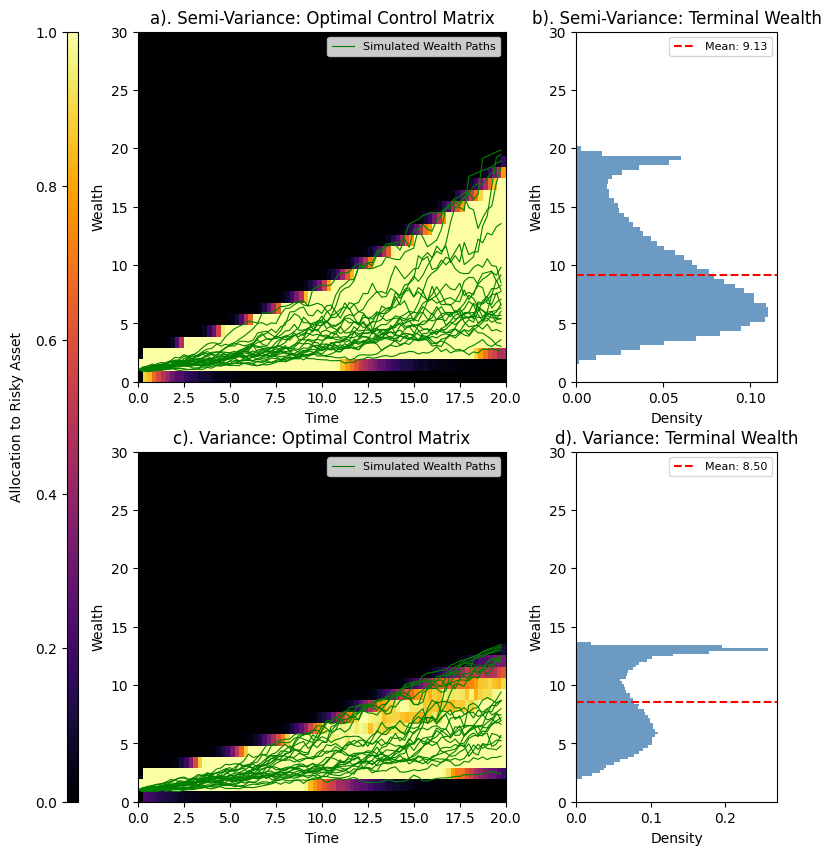

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

N_PATHS = 25  # sample wealth paths to overlay

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(2, 2, figure=fig, width_ratios=[5, 2])

configs = [
    (result_semivar, "Semi-Variance", ("a", "b")),
    (result_var,     "Variance",      ("c", "d")),
]

ax_maps = []
last_im = None

for row, (result, label, label_i) in enumerate(configs):
    policy = bilinear_policy(result.x)
    _, W_hist_sim, *_ = simulate_forward(policy)

    terminal_wealth = np.array(W_hist_sim)[-1, :]
    mean_wealth = terminal_wealth.mean()
    W_paths = np.array(W_hist_sim)[:, :N_PATHS]

    ax_map  = fig.add_subplot(gs[row, 0])
    ax_dist = fig.add_subplot(gs[row, 1])
    ax_maps.append(ax_map)

    # --- Control matrix heatmap ---
    last_im = ax_map.imshow(
        result.x.reshape((N, M)).T,
        aspect="auto",
        extent=[0, T, 0, Wmax],
        origin="lower",
        cmap="inferno",
        vmin=pmin,
        vmax=pmax,
    )

    # --- Overlay sample wealth paths ---
    for i in range(N_PATHS):
        ax_map.plot(
            time_grid, 
            W_paths[:, i], 
            color="green", 
            alpha=1, 
            linewidth=0.8, 
            label="Simulated Wealth Paths" if i == 0 else ""
        )

    ax_map.set_xlabel("Time")
    ax_map.set_ylabel("Wealth")
    ax_map.set_title(f"{label_i[0]}). {label}: Optimal Control Matrix")
    ax_map.legend(fontsize=8)
    # --- Terminal wealth distribution ---
    ax_dist.hist(
        terminal_wealth,
        bins=50,
        density=True,
        orientation="horizontal",
        color="steelblue",
        alpha=0.8,
    )
    ax_dist.axhline(mean_wealth, color="red", linestyle="--",
                    label=f"Mean: {mean_wealth:.2f}")
    ax_dist.set_xlabel("Density")
    ax_dist.set_ylabel("Wealth")
    ax_dist.set_ylim(ax_map.get_ylim())
    ax_dist.set_title(f"{label_i[1]}). {label}: Terminal Wealth")
    ax_dist.legend(fontsize=8)

# Single shared colorbar on the left spanning both heatmap rows
cbar = fig.colorbar(last_im, ax=ax_maps, location="left", pad=0.12, aspect=70)
cbar.set_label("Allocation to Risky Asset", labelpad=8)
plt.savefig("../Figs/makinen_replication.png")
plt.show()


In [ ]:
# === Adjoint MC Optimizer for Three Assets (Vectorized) === #
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import minimize

# === Model Parameters === #
r = 0.03
mu = np.array([0.0795, 0.07, 0.06])
sigma = np.array([0.15, 0.12, 0.09])
pi, w0 = 0.1, 1.0
pmin, pmax = 0.0, 1.0

T, dt, N = 20.0, 0.25, int(20.0 / 0.25)
K, Wmax, M, I = 100000, 30, 31, 3
lambda_risk = 2.0

wealth_grid = np.linspace(0, Wmax, M)
time_grid = np.linspace(0, T - dt, N)

# === Policy Function: p(t,W) returns vector of size I === #
def bilinear_policy(p_params):
    p_grid = p_params.reshape((N, M, I))
    interpolators = [RectBivariateSpline(time_grid, wealth_grid, p_grid[:, :, i], kx=1, ky=1) for i in range(I)]

    def p_func(t, W):
        W = np.clip(W, 0, Wmax)
        t = np.clip(t, 0, T - dt)
        p = np.array([interp.ev(t, W) for interp in interpolators])  # shape (I, K)
        return p.T  # shape (K, I)

    return p_func

# === Forward Simulation of Wealth Paths === #
def simulate_forward(p_func):
    W = np.full(K, w0)
    W_hist, S_hist, P_hist, dZ_hist = [], [], [], []

    for n in range(N):
        t = n * dt
        p = p_func(t, W)  # (K, I)
        drift = r + np.sum(p * (mu - r), axis=1)
        dZ = np.random.normal(0, np.sqrt(dt), (K, I))
        diffusion = np.sum(p * sigma * dZ, axis=1)
        S = 1 + drift * dt + diffusion

        W_hist.append(W.copy())
        S_hist.append(S.copy())
        P_hist.append(p.copy())
        dZ_hist.append(dZ.copy())

        W = W * S + pi * dt

    return W, W_hist, S_hist, P_hist, dZ_hist

# === Objective and Gradient using Adjoint Lagrangian === #
def objective_and_gradient(p_params):
    p_func = bilinear_policy(p_params)
    W_N, W_hist, S_hist, P_hist, dZ_hist = simulate_forward(p_func)

    mean_W, var_W = np.mean(W_N), np.var(W_N)
    J_lambda = mean_W - lambda_risk * var_W

    Y = (1 / K) - (2 * lambda_risk / K) * (W_N - mean_W)
    grad = np.zeros((N, M, I))

    for n in reversed(range(N)):
        Wn, Sn, pn, dZn = W_hist[n], S_hist[n], P_hist[n], dZ_hist[n]
        t = n * dt

        dS_dp = (mu - r) * dt + sigma * dZn  # shape (K, I)
        term = (Y * Wn)[:, None] * dS_dp  # (K, I)

        for m in range(M):
            Wm = wealth_grid[m]
            weight = np.maximum(1 - np.abs(Wn - Wm) / (Wmax / (M - 1)), 0)[:, None]
            grad[n, m, :] = np.sum(term * weight, axis=0) / K

        dS_dW = np.sum(pn * ((mu - r) * dt + sigma * dZn), axis=1) / Wn
        Y = dS_dW * Wn * Y + Sn * Y

    return -J_lambda, -grad.flatten()

# === Optimizer Interface === #
def objective(p_params):
    J, _ = objective_and_gradient(p_params)
    return J

def gradient(p_params):
    _, grad = objective_and_gradient(p_params)
    return grad

initial_p = 0.5 * np.ones((N, M, I)).flatten()
bounds = [(pmin, pmax)] * initial_p.size

result = minimize(objective, initial_p, method='L-BFGS-B', jac=gradient, bounds=bounds)

print("Optimization successful:", result.success)
print("Optimal objective value:", -result.fun)

